<a href="https://colab.research.google.com/github/aabyyaann/scikit-learn-Cookbook/blob/main/Chapter9_Text_Processing_and_Multiclass_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 9 - Text Processing and Multiclass Classification

Notebook ini membahas **pemrosesan teks (text processing)** dan **klasifikasi multikelas** menggunakan `scikit-learn`.

Topik utama pada chapter ini:
1. Pengenalan data teks dalam machine learning
2. Konversi teks menjadi fitur numerik
3. CountVectorizer dan TF-IDF
4. Penggunaan n-gram
5. Klasifikasi teks dengan Naive Bayes dan Logistic Regression
6. Strategi multiclass classification
7. Evaluasi model teks

Chapter ini dibuat sebagai reproduksi dan rangkuman dari materi **scikit-learn Cookbook** dengan gaya notebook yang rapi untuk Google Colab / GitHub.

## 1. Tujuan Pembelajaran

Setelah menyelesaikan notebook ini, kita diharapkan mampu:
- Memahami bagaimana teks direpresentasikan menjadi fitur numerik
- Menggunakan **CountVectorizer** dan **TfidfVectorizer**
- Memahami fungsi **n-gram** dalam menangkap konteks kata
- Membangun model klasifikasi teks
- Menggunakan model untuk **multiclass classification**
- Mengevaluasi performa model dengan metrik yang sesuai

In [1]:
# Import library utama
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Pengaturan visual
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Library untuk Chapter 9 berhasil diimpor.")

Library untuk Chapter 9 berhasil diimpor.


## 2. Konsep Dasar Text Processing

Data teks tidak bisa langsung diproses oleh model machine learning karena model membutuhkan **angka**, bukan kalimat mentah.

Oleh karena itu, teks harus diubah menjadi representasi numerik. Proses ini biasanya melibatkan beberapa langkah:
1. **Pembersihan teks** (opsional)
2. **Tokenisasi**: memecah kalimat menjadi kata/token
3. **Vectorization**: mengubah token menjadi angka
4. **Training model** menggunakan fitur numerik hasil vectorization

Pada scikit-learn, proses vectorization paling umum dilakukan dengan:
- **CountVectorizer** → menghitung frekuensi kemunculan kata
- **TfidfVectorizer** → memberi bobot penting pada kata berdasarkan frekuensi lokal dan global

## 3. Dataset yang Digunakan

Untuk chapter ini kita menggunakan subset dari dataset **20 Newsgroups**, yaitu kumpulan artikel berita dari beberapa kategori.

Agar proses training tidak terlalu berat di Google Colab, kita akan mengambil **4 kategori** saja:
- `sci.space`
- `comp.graphics`
- `rec.sport.baseball`
- `talk.politics.misc`

Karena ada 4 kelas, maka kasus ini termasuk **multiclass classification**.

In [2]:
categories = [
    "sci.space",
    "comp.graphics",
    "rec.sport.baseball",
    "talk.politics.misc"
]

news = fetch_20newsgroups(
    subset="all",
    categories=categories,
    remove=("headers", "footers", "quotes")
)

print("Jumlah dokumen :", len(news.data))
print("Nama kelas     :", news.target_names)
print("Distribusi label:")
print(pd.Series(news.target).value_counts().sort_index())

Jumlah dokumen : 3729
Nama kelas     : ['comp.graphics', 'rec.sport.baseball', 'sci.space', 'talk.politics.misc']
Distribusi label:
0    973
1    994
2    987
3    775
Name: count, dtype: int64


In [3]:
# Menampilkan beberapa contoh dokumen
for i in range(3):
    print(f"\n===== Dokumen ke-{i} | Label: {news.target_names[news.target[i]]} =====")
    print(news.data[i][:800])
    print("-" * 100)


===== Dokumen ke-0 | Label: rec.sport.baseball =====

Are you kidding?  I'm stuck with the Toronto SkyDome, where their idea
of a 7th inning stretch is that "Blue Jays" song where everyone gets
to yell:  "Okay, okay, Blue Jays, Blue Jays, Let's Play Ball!"

Wow.. what genius did it take to compose that one, to outshine the
old classic.  And there are women on the field to "lead the crowd".
----------------------------------------------------------------------------------------------------

===== Dokumen ke-1 | Label: talk.politics.misc =====






Sigh.  You're absolutely right.  We have no political power whatsoever. 
Therefore, we should be oppressed and ignored and denigrated, right?  I
certainly hope you don't have an SO, sir, because if she heard how
disparaging you are towards political minorities, and if she had any shred
of self-respect, she'd be out the door.



Don't count on it, sweetheart.

   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

Certainly not.  Most major universities wouldn'

## 4. Membuat DataFrame agar Lebih Mudah Dianalisis

Walaupun scikit-learn bisa langsung bekerja dengan list dokumen, membuat DataFrame sering mempermudah eksplorasi data dan dokumentasi di notebook.

In [4]:
df = pd.DataFrame({
    "text": news.data,
    "target": news.target
})

df["target_name"] = df["target"].map(lambda x: news.target_names[x])

df.head()

,text,target,target_name
0,\nAre you kidding? I'm stuck with the Toronto...,1,rec.sport.baseball
1,\n\n\n\n\n\nSigh. You're absolutely right. W...,3,talk.politics.misc
2,\n\n The above statement ignores reality. The ...,3,talk.politics.misc
3,\nI'm sorry about your friend. Really. But t...,3,talk.politics.misc
4,Hank Greenberg was probably the greatest ever....,1,rec.sport.baseball


In [5]:
print("Ukuran dataset:", df.shape)
print("\nJumlah missing text:")
print(df["text"].isna().sum())

print("\nDistribusi kelas:")
display(df["target_name"].value_counts())

Ukuran dataset: (3729, 3)

Jumlah missing text:
0

Distribusi kelas:


,count
target_name,
rec.sport.baseball,994
sci.space,987
comp.graphics,973
talk.politics.misc,775


## 5. Train-Test Split

Dataset dibagi menjadi:
- **data training** → untuk melatih model
- **data testing** → untuk mengevaluasi performa model pada data yang belum pernah dilihat sebelumnya

Kita menggunakan `stratify=y` agar proporsi tiap kelas tetap seimbang antara data train dan test.

In [6]:
X = df["text"]
y = df["target"]

text_train, text_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Jumlah data train:", len(text_train))
print("Jumlah data test :", len(text_test))

Jumlah data train: 2796
Jumlah data test : 933


# Bagian A - CountVectorizer

## 6. Mengubah Teks Menjadi Fitur dengan CountVectorizer

`CountVectorizer` mengubah kumpulan dokumen menjadi matriks angka berdasarkan **jumlah kemunculan kata**.

Contoh sederhana:
- Dokumen 1: "saya suka machine learning"
- Dokumen 2: "machine learning itu menarik"

Vocabulary yang terbentuk bisa berupa:
`["saya", "suka", "machine", "learning", "itu", "menarik"]`

Setiap dokumen kemudian direpresentasikan sebagai vektor hitungan kata.

In [7]:
vect = CountVectorizer()
X_train_counts = vect.fit_transform(text_train)
X_test_counts = vect.transform(text_test)

print("Tipe hasil transformasi:", type(X_train_counts))
print("Shape data train:", X_train_counts.shape)
print("Shape data test :", X_test_counts.shape)

Tipe hasil transformasi: <class 'scipy.sparse._csr.csr_matrix'>
Shape data train: (2796, 29627)
Shape data test : (933, 29627)


In [8]:
feature_names = vect.get_feature_names_out()

print("Jumlah kata dalam vocabulary:", len(feature_names))
print("\n20 kata pertama:")
print(feature_names[:20])

Jumlah kata dalam vocabulary: 29627

20 kata pertama:
['00' '000' '0000' '00000' '000000' '000005102000' '000062david42'
 '000100255pixel' '00041032' '0004136' '0004244402' '00043819' '0004422'
 '00044808' '0004847546' '0004988' '0005' '0005169' '0007' '00090711']


In [9]:
# Menampilkan sebagian matriks dalam bentuk DataFrame
sample_matrix = pd.DataFrame(
    X_train_counts[:5, :15].toarray(),
    columns=feature_names[:15]
)

sample_matrix

,00,000,0000,00000,000000,000005102000,000062david42,000100255pixel,00041032,0004136,0004244402,00043819,0004422,00044808,0004847546
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Penjelasan Hasil CountVectorizer

Output `CountVectorizer` adalah matriks dengan ukuran:

- **baris** = jumlah dokumen
- **kolom** = jumlah kata unik (vocabulary)
- **nilai** = frekuensi kata dalam dokumen

Karena jumlah kata unik bisa sangat banyak, hasilnya biasanya disimpan dalam bentuk **sparse matrix** agar hemat memori.

## 7. Membangun Model Teks Sederhana dengan Multinomial Naive Bayes

Algoritma **Multinomial Naive Bayes** sangat populer untuk klasifikasi teks karena:
- sederhana
- cepat
- cocok untuk fitur berbasis frekuensi kata
- sering menjadi baseline yang baik

Kita akan melatih model menggunakan fitur hasil `CountVectorizer`.

In [10]:
nb = MultinomialNB()
nb.fit(X_train_counts, y_train)

pred_nb = nb.predict(X_test_counts)

print("Akurasi Naive Bayes (CountVectorizer):", round(accuracy_score(y_test, pred_nb), 4))

Akurasi Naive Bayes (CountVectorizer): 0.8821


In [11]:
print("Classification Report - Naive Bayes + CountVectorizer")
print(classification_report(y_test, pred_nb, target_names=news.target_names))

Classification Report - Naive Bayes + CountVectorizer
                    precision    recall  f1-score   support

     comp.graphics       0.94      0.91      0.93       243
rec.sport.baseball       0.87      0.92      0.90       249
         sci.space       0.96      0.78      0.86       247
talk.politics.misc       0.77      0.92      0.84       194

          accuracy                           0.88       933
         macro avg       0.88      0.88      0.88       933
      weighted avg       0.89      0.88      0.88       933



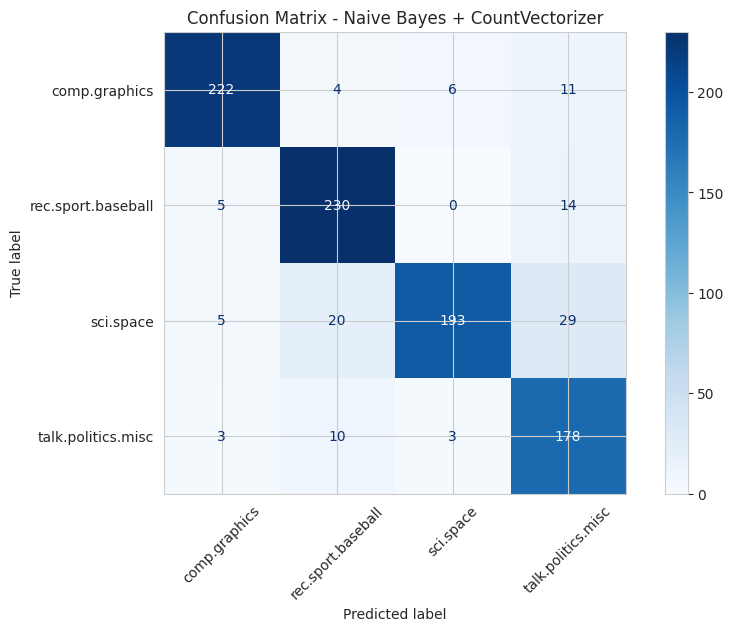

In [12]:
cm_nb = confusion_matrix(y_test, pred_nb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=news.target_names)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Naive Bayes + CountVectorizer")
plt.show()

## Interpretasi Awal

Model Naive Bayes dengan CountVectorizer sudah bisa melakukan klasifikasi multiclass pada dokumen teks.

Namun, ada beberapa keterbatasan:
- semua kata dianggap hanya berdasarkan frekuensi
- kata yang sangat umum bisa mendominasi
- konteks kata belum tertangkap dengan baik

Karena itu, kita akan mencoba representasi yang lebih informatif yaitu **TF-IDF**.

# Bagian B - TF-IDF

## 8. Text Vectorization dengan TF-IDF

**TF-IDF** adalah singkatan dari:
- **TF (Term Frequency)** → seberapa sering kata muncul dalam dokumen
- **IDF (Inverse Document Frequency)** → seberapa unik kata tersebut di seluruh dokumen

Intuisi:
- kata yang sering muncul di satu dokumen **dan**
- tidak terlalu umum di semua dokumen

akan mendapat bobot lebih besar.

Dengan TF-IDF, kata-kata yang terlalu umum cenderung diberi bobot lebih rendah.

In [13]:
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(text_train)
X_test_tfidf = tfidf.transform(text_test)

print("Shape TF-IDF train:", X_train_tfidf.shape)
print("Shape TF-IDF test :", X_test_tfidf.shape)

Shape TF-IDF train: (2796, 29627)
Shape TF-IDF test : (933, 29627)


In [14]:
tfidf_features = tfidf.get_feature_names_out()

print("Jumlah fitur TF-IDF:", len(tfidf_features))
print("15 fitur pertama:")
print(tfidf_features[:15])

Jumlah fitur TF-IDF: 29627
15 fitur pertama:
['00' '000' '0000' '00000' '000000' '000005102000' '000062david42'
 '000100255pixel' '00041032' '0004136' '0004244402' '00043819' '0004422'
 '00044808' '0004847546']


## 9. Logistic Regression pada Fitur TF-IDF

Untuk klasifikasi teks, **Logistic Regression** juga merupakan model yang sangat kuat. Pada dataset teks, model ini sering memberikan performa tinggi terutama bila digabung dengan **TF-IDF**.

Pada kasus multiclass, scikit-learn dapat menangani klasifikasi multikelas secara langsung.

In [15]:
logreg = LogisticRegression(max_iter=2000)
logreg.fit(X_train_tfidf, y_train)

pred_logreg = logreg.predict(X_test_tfidf)

print("Akurasi Logistic Regression (TF-IDF):", round(accuracy_score(y_test, pred_logreg), 4))

Akurasi Logistic Regression (TF-IDF): 0.8596


In [16]:
print("Classification Report - Logistic Regression + TF-IDF")
print(classification_report(y_test, pred_logreg, target_names=news.target_names))

Classification Report - Logistic Regression + TF-IDF
                    precision    recall  f1-score   support

     comp.graphics       0.78      0.93      0.85       243
rec.sport.baseball       0.88      0.85      0.86       249
         sci.space       0.90      0.85      0.87       247
talk.politics.misc       0.90      0.80      0.85       194

          accuracy                           0.86       933
         macro avg       0.87      0.86      0.86       933
      weighted avg       0.87      0.86      0.86       933



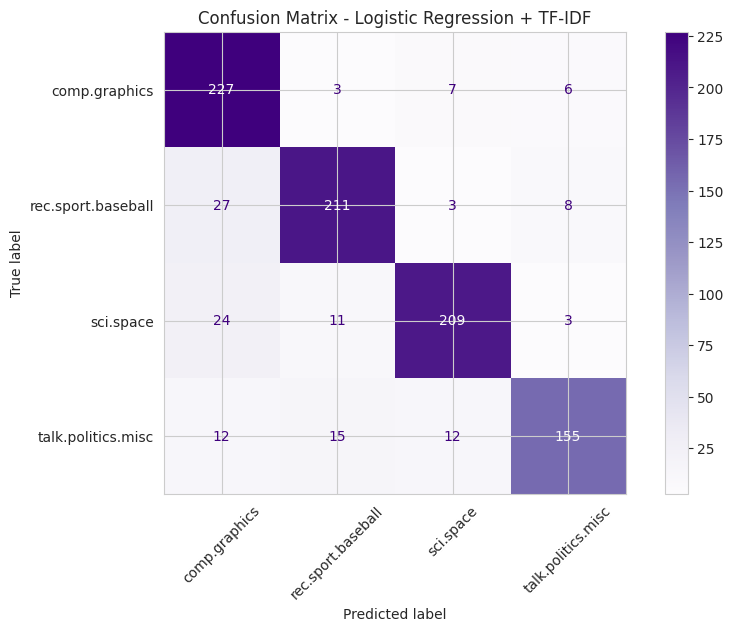

In [17]:
cm_logreg = confusion_matrix(y_test, pred_logreg)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_logreg, display_labels=news.target_names)
disp.plot(cmap="Purples", xticks_rotation=45)
plt.title("Confusion Matrix - Logistic Regression + TF-IDF")
plt.show()

## Perbandingan Awal
Sekarang kita sudah memiliki dua pendekatan:
1. **Naive Bayes + CountVectorizer**
2. **Logistic Regression + TF-IDF**

Selanjutnya kita akan membandingkan keduanya secara langsung.

In [18]:
comparison_basic = pd.DataFrame({
    "Model": [
        "MultinomialNB + CountVectorizer",
        "LogisticRegression + TF-IDF"
    ],
    "Accuracy": [
        accuracy_score(y_test, pred_nb),
        accuracy_score(y_test, pred_logreg)
    ]
})

comparison_basic.sort_values("Accuracy", ascending=False)

,Model,Accuracy
0,MultinomialNB + CountVectorizer,0.882101
1,LogisticRegression + TF-IDF,0.859593


# Bagian C - Feature Extraction dari Teks

## 10. Mengapa Feature Extraction Penting?

Dalam data teks, kualitas fitur sangat memengaruhi performa model. Dua kalimat yang mirip makna bisa terlihat berbeda jika hanya dihitung berdasarkan kata tunggal.

Contoh:
- "machine learning is powerful"
- "deep learning is powerful"

Kedua kalimat memiliki pola serupa, tetapi kata kuncinya berbeda. Untuk menangkap pola yang lebih kaya, kita bisa memakai:
- **stop words filtering**
- **minimum document frequency (`min_df`)**
- **n-gram**

## 11. Menggunakan stop words dan min_df

- **stop words**: kata-kata umum yang sering muncul tetapi kurang informatif, misalnya "the", "is", "and"
- **min_df**: hanya menyimpan kata yang muncul minimal di sejumlah dokumen tertentu

Ini membantu:
- mengurangi noise
- mengecilkan ukuran vocabulary
- mempercepat training

In [19]:
tfidf_small = TfidfVectorizer(
    stop_words="english",
    min_df=5
)

X_train_small = tfidf_small.fit_transform(text_train)
X_test_small = tfidf_small.transform(text_test)

print("Shape TF-IDF (stop_words + min_df=5):", X_train_small.shape)

Shape TF-IDF (stop_words + min_df=5): (2796, 6926)


In [20]:
logreg_small = LogisticRegression(max_iter=2000)
logreg_small.fit(X_train_small, y_train)

pred_small = logreg_small.predict(X_test_small)

print("Akurasi Logistic Regression + TF-IDF(min_df=5, stop_words='english'):",
      round(accuracy_score(y_test, pred_small), 4))

Akurasi Logistic Regression + TF-IDF(min_df=5, stop_words='english'): 0.8885


## 12. N-gram

Secara default, vectorizer bekerja pada **unigram**, yaitu satu kata sebagai satu fitur.

Contoh:
- "machine"
- "learning"
- "classification"

Dengan **bigram**, kita juga mempertimbangkan pasangan kata:
- "machine learning"
- "deep learning"
- "support vector"

Ini berguna karena beberapa makna justru muncul dari kombinasi kata, bukan dari kata tunggal.

In [21]:
tfidf_bigram = TfidfVectorizer(
    stop_words="english",
    min_df=5,
    ngram_range=(1, 2)  # unigram + bigram
)

X_train_bigram = tfidf_bigram.fit_transform(text_train)
X_test_bigram = tfidf_bigram.transform(text_test)

print("Shape TF-IDF bigram:", X_train_bigram.shape)

Shape TF-IDF bigram: (2796, 8694)


In [22]:
logreg_bigram = LogisticRegression(max_iter=2000)
logreg_bigram.fit(X_train_bigram, y_train)

pred_bigram = logreg_bigram.predict(X_test_bigram)

print("Akurasi Logistic Regression + TF-IDF Bigram:",
      round(accuracy_score(y_test, pred_bigram), 4))

Akurasi Logistic Regression + TF-IDF Bigram: 0.8917


In [23]:
comparison_features = pd.DataFrame({
    "Representasi Teks": [
        "TF-IDF default",
        "TF-IDF + stop words + min_df",
        "TF-IDF + stop words + min_df + bigram"
    ],
    "Accuracy": [
        accuracy_score(y_test, pred_logreg),
        accuracy_score(y_test, pred_small),
        accuracy_score(y_test, pred_bigram)
    ]
})

comparison_features.sort_values("Accuracy", ascending=False)

,Representasi Teks,Accuracy
2,TF-IDF + stop words + min_df + bigram,0.891747
1,TF-IDF + stop words + min_df,0.888532
0,TF-IDF default,0.859593


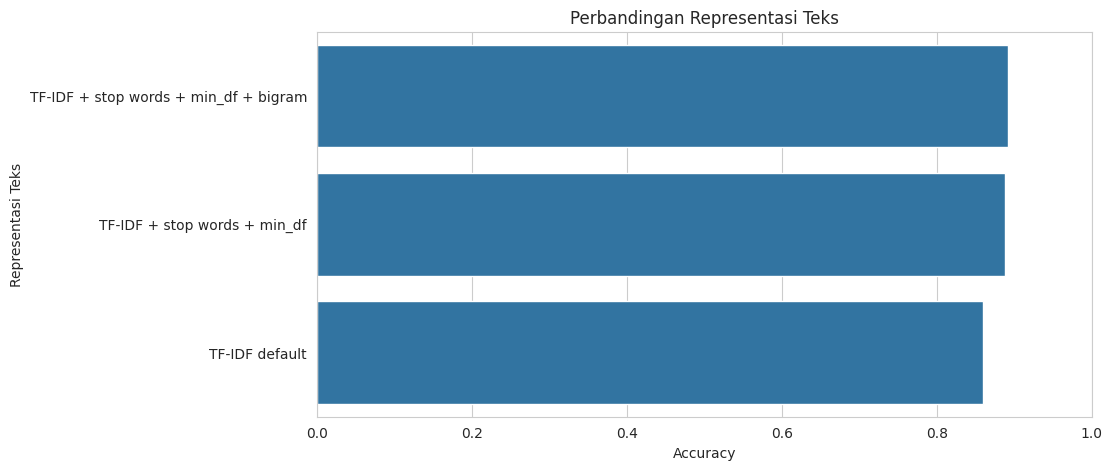

In [24]:
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_features.sort_values("Accuracy", ascending=False),
            x="Accuracy", y="Representasi Teks")
plt.title("Perbandingan Representasi Teks")
plt.xlim(0, 1)
plt.show()

## Interpretasi Hasil Feature Extraction

Dengan mengubah konfigurasi vectorizer, performa model bisa meningkat atau menurun. Hal ini menunjukkan bahwa **feature engineering pada data teks sangat penting**.

Beberapa pengamatan umum:
- `stop_words` membantu menghapus kata umum yang kurang penting
- `min_df` membantu mengurangi kata yang terlalu jarang
- `n-gram` dapat menangkap konteks dua kata sekaligus

Namun, n-gram juga menambah jumlah fitur secara signifikan sehingga training bisa lebih berat.

# Bagian D - Multiclass Classification

## 13. Apa itu Multiclass Classification?

**Multiclass classification** adalah tugas klasifikasi dengan **lebih dari dua kelas**.

Contoh:
- klasifikasi berita ke kategori olahraga / politik / teknologi / sains
- klasifikasi email ke beberapa label
- klasifikasi sentimen multi-level

Pada chapter ini, dataset kita memiliki 4 kelas, sehingga termasuk multiclass classification.

## 14. Strategi One-vs-Rest (OvR)

Salah satu strategi umum untuk multiclass classification adalah **One-vs-Rest (OvR)**.

Ide utamanya:
- untuk setiap kelas, buat satu model biner:
  - kelas tersebut = positif
  - semua kelas lain = negatif
- ulangi untuk semua kelas
- pilih kelas dengan skor tertinggi

Walaupun Logistic Regression di scikit-learn sudah mendukung multiclass, kita tetap akan mencoba **OneVsRestClassifier** untuk memahami konsep ini.

In [25]:
ovr_model = OneVsRestClassifier(LogisticRegression(max_iter=2000))
ovr_model.fit(X_train_tfidf, y_train)

pred_ovr = ovr_model.predict(X_test_tfidf)

print("Akurasi One-vs-Rest Logistic Regression:",
      round(accuracy_score(y_test, pred_ovr), 4))

Akurasi One-vs-Rest Logistic Regression: 0.8553


In [26]:
print("Classification Report - OneVsRest + Logistic Regression")
print(classification_report(y_test, pred_ovr, target_names=news.target_names))

Classification Report - OneVsRest + Logistic Regression
                    precision    recall  f1-score   support

     comp.graphics       0.77      0.93      0.85       243
rec.sport.baseball       0.87      0.85      0.86       249
         sci.space       0.90      0.83      0.87       247
talk.politics.misc       0.91      0.79      0.85       194

          accuracy                           0.86       933
         macro avg       0.86      0.85      0.86       933
      weighted avg       0.86      0.86      0.86       933



In [27]:
comparison_multiclass = pd.DataFrame({
    "Model": [
        "Logistic Regression (multiclass default)",
        "One-vs-Rest Logistic Regression"
    ],
    "Accuracy": [
        accuracy_score(y_test, pred_logreg),
        accuracy_score(y_test, pred_ovr)
    ]
})

comparison_multiclass

,Model,Accuracy
0,Logistic Regression (multiclass default),0.859593
1,One-vs-Rest Logistic Regression,0.855305


## 15. Melihat Kata-Kata yang Paling Berpengaruh

Salah satu kelebihan model linear seperti Logistic Regression adalah kita bisa melihat fitur mana yang paling berkontribusi pada tiap kelas.

Untuk klasifikasi teks, fitur tersebut adalah kata atau n-gram tertentu.

In [28]:
feature_names = tfidf.get_feature_names_out()

coef_df = pd.DataFrame(logreg.coef_.T, index=feature_names, columns=news.target_names)
coef_df.head()

,comp.graphics,rec.sport.baseball,sci.space,talk.politics.misc
00,0.289538,-0.107270,-0.052045,-0.130223
000,-0.233093,0.382858,-0.025879,-0.123886
0000,-0.016433,-0.007808,0.029164,-0.004924
00000,-0.063192,-0.027588,0.108188,-0.017408
000000,-0.000209,-0.000104,0.000417,-0.000105


In [29]:
# Menampilkan 10 kata dengan koefisien terbesar untuk setiap kelas
for i, class_name in enumerate(news.target_names):
    top_features = np.argsort(logreg.coef_[i])[-10:]
    print(f"\nKelas: {class_name}")
    print(feature_names[top_features])


Kelas: comp.graphics
['ve' 'program' 'code' 'hi' 'files' '3d' 'computer' 'file' 'image'
 'graphics']

Kelas: rec.sport.baseball
['cubs' 'stats' 'league' 'year' 'players' 'games' 'team' 'game' 'baseball'
 'he']

Kelas: sci.space
['earth' 'sky' 'solar' 'spacecraft' 'moon' 'launch' 'shuttle' 'nasa'
 'orbit' 'space']

Kelas: talk.politics.misc
['state' 'gay' 'who' 'tax' 'men' 'drugs' 'that' 'government' 'people'
 'clinton']


## Interpretasi Koefisien

Pada Logistic Regression:
- koefisien positif yang besar menunjukkan kata tersebut mendukung kelas tertentu
- koefisien negatif menunjukkan kata tersebut kurang mendukung kelas tersebut

Misalnya:
- kelas `sci.space` mungkin kuat dipengaruhi oleh kata seperti `space`, `nasa`, `orbit`
- kelas `comp.graphics` mungkin dipengaruhi oleh kata seperti `image`, `graphics`, `file`
- kelas `rec.sport.baseball` mungkin dipengaruhi oleh kata seperti `game`, `baseball`, `team`

# Bagian E - Evaluasi Model Teks

## 16. Mengapa Evaluasi Penting?

Dalam klasifikasi teks, akurasi saja kadang belum cukup. Kita juga perlu melihat:
- **precision** → seberapa banyak prediksi positif yang benar
- **recall** → seberapa banyak data positif yang berhasil ditemukan
- **f1-score** → rata-rata harmonik precision dan recall
- **confusion matrix** → pola kesalahan antar kelas

Pada multiclass classification, confusion matrix sangat membantu untuk melihat kelas mana yang sering tertukar.

In [30]:
best_pred = pred_bigram  # kita gunakan model bigram sebagai kandidat terbaik
best_name = "Logistic Regression + TF-IDF Bigram"

print("Model evaluasi akhir:", best_name)
print("Accuracy:", round(accuracy_score(y_test, best_pred), 4))
print()
print(classification_report(y_test, best_pred, target_names=news.target_names))

Model evaluasi akhir: Logistic Regression + TF-IDF Bigram
Accuracy: 0.8917

                    precision    recall  f1-score   support

     comp.graphics       0.94      0.94      0.94       243
rec.sport.baseball       0.91      0.85      0.88       249
         sci.space       0.81      0.93      0.87       247
talk.politics.misc       0.93      0.84      0.88       194

          accuracy                           0.89       933
         macro avg       0.90      0.89      0.89       933
      weighted avg       0.90      0.89      0.89       933



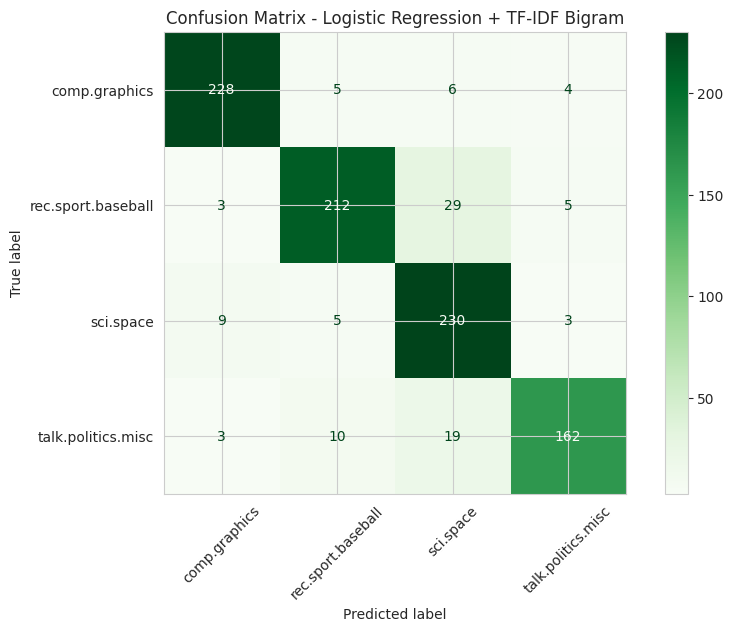

In [31]:
cm_best = confusion_matrix(y_test, best_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=news.target_names)
disp.plot(cmap="Greens", xticks_rotation=45)
plt.title(f"Confusion Matrix - {best_name}")
plt.show()

## 17. Analisis Kesalahan Prediksi

Selain melihat angka evaluasi, kita juga perlu memeriksa contoh dokumen yang salah klasifikasi. Ini penting untuk memahami:
- apakah isi dokumen memang ambigu
- apakah kelas memiliki kosakata yang mirip
- apakah preprocessing masih kurang baik

In [32]:
# Gunakan model bigram
pred_series = pd.Series(best_pred, index=text_test.index)

errors = pd.DataFrame({
    "text": text_test,
    "actual": y_test,
    "predicted": pred_series
})

errors = errors[errors["actual"] != errors["predicted"]].copy()
errors["actual_name"] = errors["actual"].map(lambda x: news.target_names[x])
errors["predicted_name"] = errors["predicted"].map(lambda x: news.target_names[x])

print("Jumlah salah prediksi:", len(errors))
errors.head(10)

Jumlah salah prediksi: 101


,text,actual,predicted,actual_name,predicted_name
2402,\nWho compared Quayle to Gore? Mark said he h...,3,1,talk.politics.misc,rec.sport.baseball
3526,"\n\tHeheheheh.. Sorry, Roger, I wronged you.. ...",1,3,rec.sport.baseball,talk.politics.misc
160,,1,2,rec.sport.baseball,sci.space
1247,\nNo. That's *not* what I was complaining abo...,0,3,comp.graphics,talk.politics.misc
2252,,1,2,rec.sport.baseball,sci.space
1731,"\nI agree with the body of your post, but plea...",3,1,talk.politics.misc,rec.sport.baseball
854,"Oops, I forgot to set read permission. It's f...",3,0,talk.politics.misc,comp.graphics
146,\nGreat speculation - I remember being proud o...,2,1,sci.space,rec.sport.baseball
1499,,0,2,comp.graphics,sci.space
1125,\n\n,1,2,rec.sport.baseball,sci.space


In [33]:
if len(errors) > 0:
    sample_error = errors.iloc[0]
    print("Label sebenarnya :", sample_error["actual_name"])
    print("Label prediksi   :", sample_error["predicted_name"])
    print("\nIsi dokumen:\n")
    print(sample_error["text"][:2000])
else:
    print("Tidak ada error prediksi pada sampel yang dipilih.")

Label sebenarnya : talk.politics.misc
Label prediksi   : rec.sport.baseball

Isi dokumen:


Who compared Quayle to Gore?  Mark said he had never heard of any incident
in which the thrower of the ceremonial ball had been booed before.  I mentioned
another incident.  (And if the media had a liberal bias, I'm sure he would
have heard of the Quayle incident.)

If I was to compare Quayle to anyone, it most likely would be Elmer Fudd.




# Bagian F - Praktik Ringkas Tambahan

## 18. Perbandingan Naive Bayes vs Logistic Regression

Sekarang kita rangkum beberapa model yang sudah dicoba:
1. **Multinomial Naive Bayes + CountVectorizer**
2. **Logistic Regression + TF-IDF**
3. **Logistic Regression + TF-IDF (stop words, min_df)**
4. **Logistic Regression + TF-IDF bigram**
5. **One-vs-Rest Logistic Regression**

In [34]:
summary_models = pd.DataFrame({
    "Model": [
        "MultinomialNB + CountVectorizer",
        "Logistic Regression + TF-IDF",
        "Logistic Regression + TF-IDF (cleaner vocab)",
        "Logistic Regression + TF-IDF Bigram",
        "OneVsRest Logistic Regression + TF-IDF"
    ],
    "Accuracy": [
        accuracy_score(y_test, pred_nb),
        accuracy_score(y_test, pred_logreg),
        accuracy_score(y_test, pred_small),
        accuracy_score(y_test, pred_bigram),
        accuracy_score(y_test, pred_ovr)
    ]
})

summary_models = summary_models.sort_values("Accuracy", ascending=False)
summary_models

,Model,Accuracy
3,Logistic Regression + TF-IDF Bigram,0.891747
2,Logistic Regression + TF-IDF (cleaner vocab),0.888532
0,MultinomialNB + CountVectorizer,0.882101
1,Logistic Regression + TF-IDF,0.859593
4,OneVsRest Logistic Regression + TF-IDF,0.855305


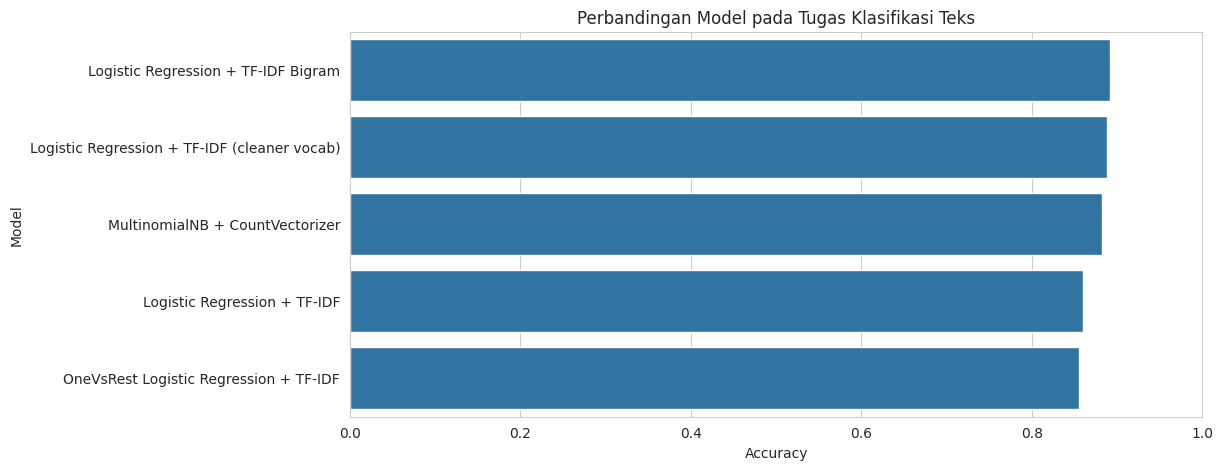

In [35]:
plt.figure(figsize=(11, 5))
sns.barplot(data=summary_models, x="Accuracy", y="Model")
plt.title("Perbandingan Model pada Tugas Klasifikasi Teks")
plt.xlim(0, 1)
plt.show()

# Bagian G - Practical Exercises

## 19. Exercise 1 - Preprocessing dan Vectorizing Text

Pada latihan pertama, kita ingin melihat bagaimana teks diubah menjadi fitur numerik.

Langkah:
1. Ambil beberapa dokumen contoh
2. Gunakan `CountVectorizer`
3. Tampilkan vocabulary dan matriks hasil transformasi

In [36]:
sample_docs = [
    "machine learning is fun",
    "machine learning uses data",
    "data science and machine learning are related",
    "sports and baseball are exciting"
]

sample_vect = CountVectorizer()
sample_matrix = sample_vect.fit_transform(sample_docs)

sample_df = pd.DataFrame(
    sample_matrix.toarray(),
    columns=sample_vect.get_feature_names_out()
)

sample_df

,and,are,baseball,data,exciting,fun,is,learning,machine,related,science,sports,uses
0,0,0,0,0,0,1,1,1,1,0,0,0,0
1,0,0,0,1,0,0,0,1,1,0,0,0,1
2,1,1,0,1,0,0,0,1,1,1,1,0,0
3,1,1,1,0,1,0,0,0,0,0,0,1,0


## 20. Exercise 2 - Feature Extraction dengan n-grams

Kita akan melihat perbedaan vocabulary antara:
- unigram
- unigram + bigram

In [37]:
vect_uni = CountVectorizer(ngram_range=(1, 1))
vect_bi = CountVectorizer(ngram_range=(1, 2))

vect_uni.fit(sample_docs)
vect_bi.fit(sample_docs)

print("Jumlah fitur unigram:", len(vect_uni.get_feature_names_out()))
print("Jumlah fitur unigram+bigram:", len(vect_bi.get_feature_names_out()))

print("\nContoh fitur unigram:")
print(vect_uni.get_feature_names_out()[:20])

print("\nContoh fitur unigram + bigram:")
print(vect_bi.get_feature_names_out()[:30])

Jumlah fitur unigram: 13
Jumlah fitur unigram+bigram: 27

Contoh fitur unigram:
['and' 'are' 'baseball' 'data' 'exciting' 'fun' 'is' 'learning' 'machine'
 'related' 'science' 'sports' 'uses']

Contoh fitur unigram + bigram:
['and' 'and baseball' 'and machine' 'are' 'are exciting' 'are related'
 'baseball' 'baseball are' 'data' 'data science' 'exciting' 'fun' 'is'
 'is fun' 'learning' 'learning are' 'learning is' 'learning uses'
 'machine' 'machine learning' 'related' 'science' 'science and' 'sports'
 'sports and' 'uses' 'uses data']


## 21. Exercise 3 - Membangun dan Mengevaluasi Multiclass Classifier

Pada latihan terakhir, kita melatih model klasifikasi multiclass menggunakan konfigurasi terbaik dari notebook ini, lalu mengevaluasinya.

In [38]:
final_vectorizer = TfidfVectorizer(
    stop_words="english",
    min_df=5,
    ngram_range=(1, 2)
)

X_train_final = final_vectorizer.fit_transform(text_train)
X_test_final = final_vectorizer.transform(text_test)

final_model = LogisticRegression(max_iter=2000)
final_model.fit(X_train_final, y_train)

final_pred = final_model.predict(X_test_final)

print("Final model accuracy:", round(accuracy_score(y_test, final_pred), 4))
print()
print(classification_report(y_test, final_pred, target_names=news.target_names))

Final model accuracy: 0.8917

                    precision    recall  f1-score   support

     comp.graphics       0.94      0.94      0.94       243
rec.sport.baseball       0.91      0.85      0.88       249
         sci.space       0.81      0.93      0.87       247
talk.politics.misc       0.93      0.84      0.88       194

          accuracy                           0.89       933
         macro avg       0.90      0.89      0.89       933
      weighted avg       0.90      0.89      0.89       933



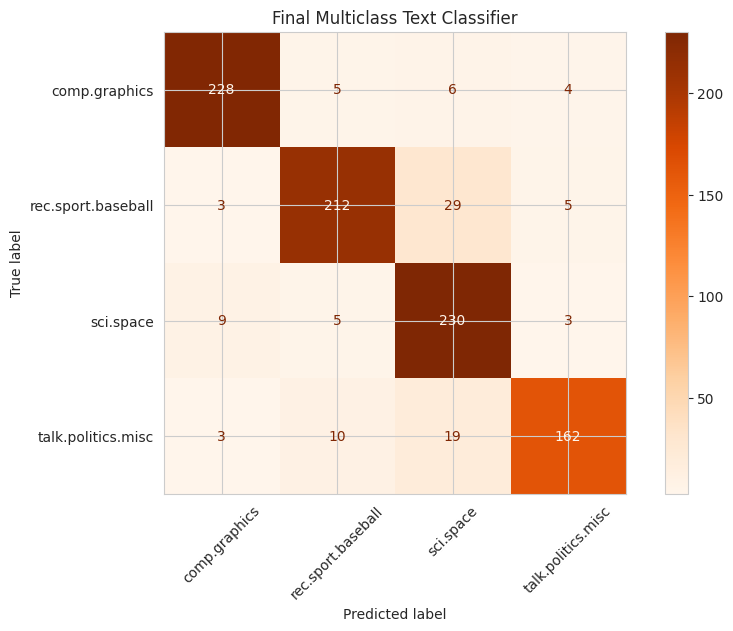

In [39]:
final_cm = confusion_matrix(y_test, final_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=final_cm, display_labels=news.target_names)
disp.plot(cmap="Oranges", xticks_rotation=45)
plt.title("Final Multiclass Text Classifier")
plt.show()

# 22. Ringkasan Teori Chapter 9

Berikut poin-poin penting dari chapter ini:

### a. Teks harus diubah menjadi fitur numerik
Model machine learning tidak bisa langsung membaca kalimat mentah. Karena itu, teks harus dikonversi menjadi angka menggunakan teknik vectorization.

### b. CountVectorizer menghitung frekuensi kata
Pendekatan ini sederhana dan sering dipakai sebagai baseline awal. Setiap dokumen direpresentasikan berdasarkan jumlah kemunculan kata.

### c. TF-IDF memberi bobot penting pada kata
TF-IDF memperhitungkan tidak hanya frekuensi kata dalam satu dokumen, tetapi juga seberapa umum kata tersebut di seluruh korpus.

### d. Feature engineering pada teks sangat penting
Penggunaan `stop_words`, `min_df`, dan `n-gram` dapat memengaruhi performa model secara signifikan.

### e. Multiclass classification menangani lebih dari dua kelas
Dalam dataset 20 Newsgroups, kita mengklasifikasikan dokumen ke beberapa kategori sekaligus, sehingga masalahnya termasuk multiclass classification.

### f. Evaluasi model tidak hanya akurasi
Kita juga perlu melihat precision, recall, f1-score, dan confusion matrix untuk memahami perilaku model secara lebih lengkap.

# 23. Kesimpulan Chapter 9

Pada chapter ini kita mempelajari bagaimana **data teks** diproses dalam machine learning hingga dapat digunakan untuk **klasifikasi multikelas**.

Hal-hal utama yang dipelajari:
1. Dataset teks perlu diubah menjadi fitur numerik melalui **CountVectorizer** atau **TF-IDF**
2. **CountVectorizer** menggunakan frekuensi kata, sedangkan **TF-IDF** menimbang pentingnya kata
3. **n-gram** membantu menangkap konteks kombinasi kata
4. Model seperti **Multinomial Naive Bayes** dan **Logistic Regression** cocok untuk klasifikasi teks
5. Masalah klasifikasi dengan lebih dari dua label termasuk **multiclass classification**
6. Evaluasi model dilakukan dengan **accuracy, classification report, dan confusion matrix**
7. Dalam praktik, kualitas preprocessing dan feature extraction sangat memengaruhi hasil akhir model

Secara umum, chapter ini menunjukkan bahwa keberhasilan text classification tidak hanya bergantung pada algoritma, tetapi juga pada bagaimana teks direpresentasikan menjadi fitur.

# 24. Penutup

Notebook Chapter 9 ini merangkum materi:
- text processing
- vectorization
- TF-IDF
- n-gram
- text classification
- multiclass classification
- evaluasi model teks

Notebook ini dapat dijadikan dasar untuk tugas-tugas NLP sederhana menggunakan scikit-learn.